In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [2]:
df = pd.read_csv("../data/raw/mumbai-house-price-data-cleaned.csv")

print("Raw dataset loaded successfully!")
print("Shape:", df.shape)

Raw dataset loaded successfully!
Shape: (71938, 15)


In [3]:
clean_df = df.copy()

print("Working copy created.")
print("Shape:", clean_df.shape)

Working copy created.
Shape: (71938, 15)


In [4]:
print("Columns before cleaning:")

for i, column in enumerate(clean_df.columns, start=1):
    print(f"{i}. {column}")

Columns before cleaning:
1. title
2. price
3. area
4. price_per_sqft
5. locality
6. city
7. property_type
8. bedroom_num
9. bathroom_num
10. balcony_num
11. furnished
12. age
13. total_floors
14. latitude
15. longitude


In [5]:
duplicate_count = clean_df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 20171


In [6]:
before = len(clean_df)

clean_df = clean_df.drop_duplicates().reset_index(drop=True)

after = len(clean_df)

print("Rows before removing duplicates:", before)
print("Rows after removing duplicates:", after)
print("Duplicates removed:", before - after)

Rows before removing duplicates: 71938
Rows after removing duplicates: 51767
Duplicates removed: 20171


In [7]:
missing_values = clean_df.isnull().sum()

missing_table = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage": (missing_values / len(clean_df)) * 100
})

missing_table = missing_table.sort_values(
    by="Missing Percentage",
    ascending=False
)

missing_table

,Missing Values,Missing Percentage
title,0,0.0
price,0,0.0
area,0,0.0
price_per_sqft,0,0.0
locality,0,0.0
city,0,0.0
property_type,0,0.0
bedroom_num,0,0.0
bathroom_num,0,0.0
balcony_num,0,0.0


In [8]:
print(clean_df.dtypes)

title                 str
price               int64
area                int64
price_per_sqft    float64
locality              str
city                  str
property_type         str
bedroom_num         int64
bathroom_num        int64
balcony_num         int64
furnished             str
age                 int64
total_floors        int64
latitude          float64
longitude         float64
dtype: object


In [9]:
numerical_columns = clean_df.select_dtypes(
    include=np.number
).columns.tolist()

print("Numerical columns:")
print(numerical_columns)

Numerical columns:
['price', 'area', 'price_per_sqft', 'bedroom_num', 'bathroom_num', 'balcony_num', 'age', 'total_floors', 'latitude', 'longitude']


In [10]:
categorical_columns = clean_df.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Categorical columns:")
print(categorical_columns)

Categorical columns:
['title', 'locality', 'city', 'property_type', 'furnished']


C:\Users\Tejas Dalvi\AppData\Local\Temp\ipykernel_19444\1691845845.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = clean_df.select_dtypes(


In [11]:
for column in categorical_columns:
    print("\n" + "=" * 60)
    print("Column:", column)
    print("Number of unique values:", clean_df[column].nunique())
    print("Sample values:")
    print(clean_df[column].dropna().unique()[:30])


Column: title
Number of unique values: 9277
Sample values:
<StringArray>
[                                                  'Octave Parijas Horizon',
                                                    'Shakti Siyara Heights',
                                                'Bhagwati Bhagwati Celeste',
 'Relcon Ridhi Sidhi Sadan Of Ridhi Sidhi Co Operative Housing Society Ltd',
                                                        'J P Ruchita Bliss',
                                                            'Saras Destiny',
                                                     'Nexus Ratan Heritage',
                                   'Aristocrat Guruprasad Divine Residency',
                                                              '9 PBR 9 PBR',
                'Prestige Bellanza Phase 2 Wing D E F At The Prestige City',
                                                           'Konark Darshan',
                                                          'Mahaavir Mannat',
  

In [12]:
clean_df[numerical_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
price,51767.0,2.029837e+07,3.467431e+07,32000.000000,6.500000e+06,1.200000e+07,2.200000e+07,2.147484e+09
area,51767.0,9.736820e+02,6.618316e+02,123.000000,6.100000e+02,8.040000e+02,1.144000e+03,2.410900e+04
price_per_sqft,51767.0,1.839029e+04,1.309981e+04,25.376685,8.901539e+03,1.564200e+04,2.385566e+04,2.900000e+05
bedroom_num,51767.0,2.000444e+00,9.294450e-01,0.000000,1.000000e+00,2.000000e+00,3.000000e+00,1.500000e+01
bathroom_num,51767.0,2.100836e+00,8.627529e-01,1.000000,2.000000e+00,2.000000e+00,2.000000e+00,1.500000e+01
balcony_num,51767.0,1.644677e-01,5.927436e-01,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,1.500000e+01
age,51767.0,2.363919e+00,4.377339e+00,0.000000,0.000000e+00,0.000000e+00,3.000000e+00,5.700000e+01
total_floors,51767.0,1.003748e+00,3.237341e-01,1.000000,1.000000e+00,1.000000e+00,1.000000e+00,7.000000e+01
latitude,51767.0,1.917294e+01,5.329514e-01,12.889899,1.906977e+01,1.916048e+01,1.922804e+01,7.286834e+01
longitude,51767.0,7.296670e+01,4.577374e-01,72.435379,7.285671e+01,7.291319e+01,7.302120e+01,9.180441e+01


In [13]:
print("Price <= 0:", (clean_df["price"] <= 0).sum())
print("Area <= 0:", (clean_df["area"] <= 0).sum())

Price <= 0: 0
Area <= 0: 0


In [14]:
before = len(clean_df)

clean_df = clean_df[
    (clean_df["price"] > 0) &
    (clean_df["area"] > 0)
].copy()

clean_df.reset_index(drop=True, inplace=True)

after = len(clean_df)

print("Rows before:", before)
print("Rows after:", after)
print("Invalid rows removed:", before - after)

Rows before: 51767
Rows after: 51767
Invalid rows removed: 0


In [15]:
print("Bedroom values:")
print(sorted(clean_df["bedroom_num"].dropna().unique()))

Bedroom values:
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(12), np.int64(15)]


In [16]:
print("Bathroom values:")
print(sorted(clean_df["bathroom_num"].dropna().unique()))

Bathroom values:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(12), np.int64(15)]


In [17]:
print("Balcony values:")
print(sorted(clean_df["balcony_num"].dropna().unique()))

Balcony values:
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(8), np.int64(10), np.int64(12), np.int64(15)]


In [18]:
print("Property age statistics:")
print(clean_df["age"].describe())

print("\nUnique age values:")
print(sorted(clean_df["age"].dropna().unique()))

Property age statistics:
count    51767.000000
mean         2.363919
std          4.377339
min          0.000000
25%          0.000000
50%          0.000000
75%          3.000000
max         57.000000
Name: age, dtype: float64

Unique age values:
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(48), np.int64(49), np.int64(50), np.int64(51), np.int64(53), np.int64(54), np.int64(55), np.int64(57)]


In [19]:
print("Total floors statistics:")
print(clean_df["total_floors"].describe())

print("\nUnique floor values:")
print(sorted(clean_df["total_floors"].dropna().unique()))

Total floors statistics:
count    51767.000000
mean         1.003748
std          0.323734
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         70.000000
Name: total_floors, dtype: float64

Unique floor values:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(14), np.int64(70)]


In [20]:
print("Number of unique localities:",
      clean_df["locality"].nunique())

print("\nTop 20 localities:")

print(
    clean_df["locality"]
    .value_counts()
    .head(20)
)

Number of unique localities: 408

Top 20 localities:
locality
Thane        5292
Mira Road    3162
Andheri      2039
Kandivali    2039
Kharghar     1904
Dombivali    1872
Kalyan       1738
Borivali     1678
Chembur      1591
Malad        1522
Mulund       1446
Goregaon     1287
Panvel       1227
Ulwe         1140
Ambernath     981
Powai         917
Ghatkopar     906
Vikhroli      900
Virar         771
Vasai         752
Name: count, dtype: int64


In [21]:
text_columns = clean_df.select_dtypes(
    include=["object"]
).columns

for column in text_columns:
    clean_df[column] = clean_df[column].astype(str).str.strip()

print("Text columns cleaned.")

Text columns cleaned.


C:\Users\Tejas Dalvi\AppData\Local\Temp\ipykernel_19444\2441394012.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_columns = clean_df.select_dtypes(


In [22]:
clean_df = clean_df.replace(
    ["nan", "NaN", "None", ""],
    np.nan
)

print("Missing-value representations standardized.")

Missing-value representations standardized.


In [23]:
missing_after_text_cleaning = pd.DataFrame({
    "Missing Values": clean_df.isnull().sum(),
    "Percentage": (clean_df.isnull().sum() / len(clean_df)) * 100
})

missing_after_text_cleaning[
    missing_after_text_cleaning["Missing Values"] > 0
]

,Missing Values,Percentage
title,9591,18.527247


In [24]:
numeric_fill_columns = [
    "area",
    "bedroom_num",
    "bathroom_num",
    "balcony_num",
    "age",
    "total_floors",
    "latitude",
    "longitude"
]

for column in numeric_fill_columns:
    if column in clean_df.columns:
        clean_df[column] = clean_df[column].fillna(
            clean_df[column].median()
        )

print("Numerical missing values handled.")

Numerical missing values handled.


In [25]:
categorical_fill_columns = [
    "locality",
    "city",
    "property_type",
    "furnished"
]

for column in categorical_fill_columns:
    if column in clean_df.columns:
        clean_df[column] = clean_df[column].fillna("Unknown")

print("Categorical missing values handled.")

Categorical missing values handled.


In [26]:
remaining_missing = clean_df.isnull().sum()

remaining_missing = remaining_missing[
    remaining_missing > 0
]

print("Remaining missing values:")

if len(remaining_missing) == 0:
    print("No missing values remaining.")
else:
    print(remaining_missing)

Remaining missing values:
title    9591
dtype: int64


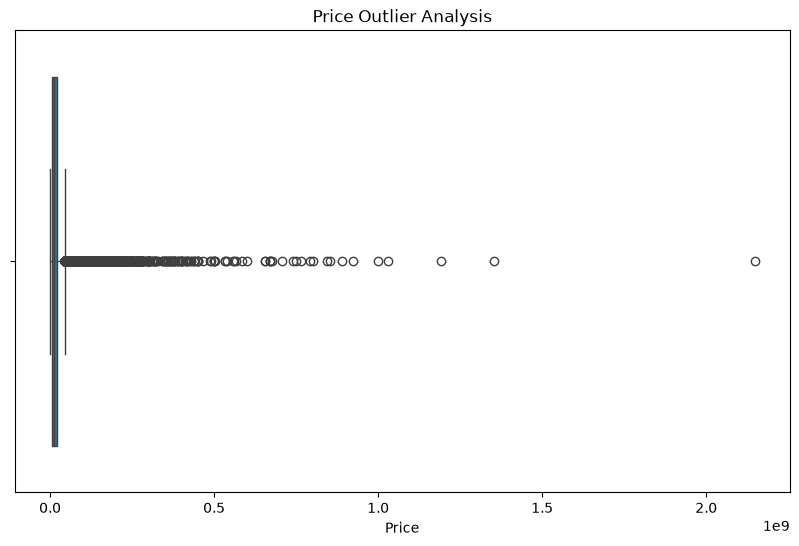

In [27]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    x=clean_df["price"]
)

plt.title("Price Outlier Analysis")
plt.xlabel("Price")

plt.show()

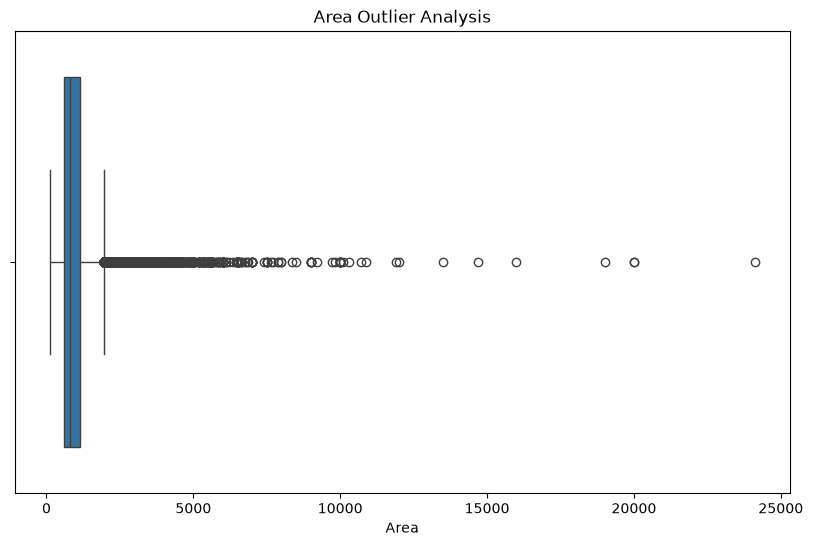

In [28]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    x=clean_df["area"]
)

plt.title("Area Outlier Analysis")
plt.xlabel("Area")

plt.show()

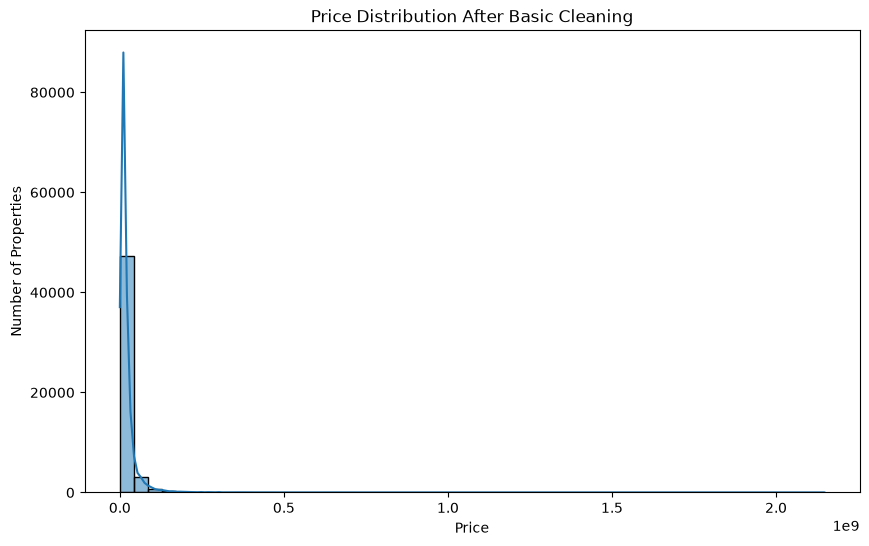

In [30]:
plt.figure(figsize=(10, 6))

sns.histplot(
    clean_df["price"],
    bins=50,
    kde=True
)

plt.title("Price Distribution After Basic Cleaning")
plt.xlabel("Price")
plt.ylabel("Number of Properties")

plt.show()

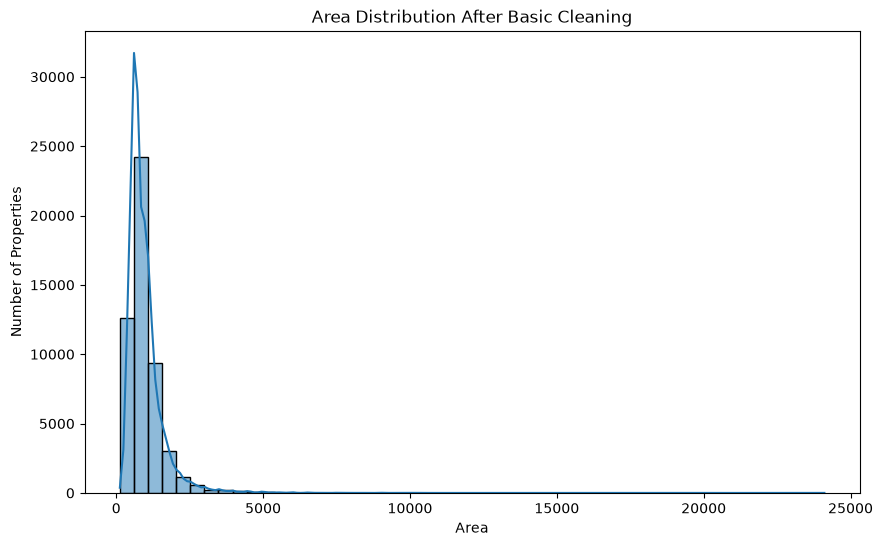

In [31]:
plt.figure(figsize=(10, 6))

sns.histplot(
    clean_df["area"],
    bins=50,
    kde=True
)

plt.title("Area Distribution After Basic Cleaning")
plt.xlabel("Area")
plt.ylabel("Number of Properties")

plt.show()

In [32]:
calculated_price_per_sqft = (
    clean_df["price"] / clean_df["area"]
)

difference = (
    calculated_price_per_sqft -
    clean_df["price_per_sqft"]
).abs()

print("Maximum difference:",
      difference.max())

print("Average difference:",
      difference.mean())

Maximum difference: 2.9103830456733704e-11
Average difference: 3.803909964741011e-13


In [33]:
clean_df["price_per_sqft"] = (
    clean_df["price"] / clean_df["area"]
)

print("price_per_sqft recalculated successfully.")

price_per_sqft recalculated successfully.


In [34]:
print("Latitude:")
print(clean_df["latitude"].describe())

print("\nLongitude:")
print(clean_df["longitude"].describe())

Latitude:
count    51767.000000
mean        19.172944
std          0.532951
min         12.889899
25%         19.069774
50%         19.160484
75%         19.228041
max         72.868339
Name: latitude, dtype: float64

Longitude:
count    51767.000000
mean        72.966697
std          0.457737
min         72.435379
25%         72.856712
50%         72.913185
75%         73.021202
max         91.804413
Name: longitude, dtype: float64


In [35]:
if "id" in clean_df.columns:
    clean_df = clean_df.drop(columns=["id"])

print("Columns after removing ID:")
print(clean_df.columns.tolist())

Columns after removing ID:
['title', 'price', 'area', 'price_per_sqft', 'locality', 'city', 'property_type', 'bedroom_num', 'bathroom_num', 'balcony_num', 'furnished', 'age', 'total_floors', 'latitude', 'longitude']


In [36]:
if "title" in clean_df.columns:
    clean_df = clean_df.drop(columns=["title"])

print("Title column removed.")

Title column removed.


In [37]:
print("Final columns after basic cleaning:")

for i, column in enumerate(clean_df.columns, start=1):
    print(f"{i}. {column}")

Final columns after basic cleaning:
1. price
2. area
3. price_per_sqft
4. locality
5. city
6. property_type
7. bedroom_num
8. bathroom_num
9. balcony_num
10. furnished
11. age
12. total_floors
13. latitude
14. longitude


In [38]:
print("Final number of rows:", clean_df.shape[0])
print("Final number of columns:", clean_df.shape[1])

Final number of rows: 51767
Final number of columns: 14


In [39]:
print("Total missing values:",
      clean_df.isnull().sum().sum())

if clean_df.isnull().sum().sum() == 0:
    print("Dataset has no missing values.")
else:
    print("Some missing values still exist.")

Total missing values: 0
Dataset has no missing values.


In [40]:
print("Remaining duplicate rows:",
      clean_df.duplicated().sum())

Remaining duplicate rows: 114


In [41]:
clean_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 51767 entries, 0 to 51766
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   price           51767 non-null  int64  
 1   area            51767 non-null  int64  
 2   price_per_sqft  51767 non-null  float64
 3   locality        51767 non-null  str    
 4   city            51767 non-null  str    
 5   property_type   51767 non-null  str    
 6   bedroom_num     51767 non-null  int64  
 7   bathroom_num    51767 non-null  int64  
 8   balcony_num     51767 non-null  int64  
 9   furnished       51767 non-null  str    
 10  age             51767 non-null  int64  
 11  total_floors    51767 non-null  int64  
 12  latitude        51767 non-null  float64
 13  longitude       51767 non-null  float64
dtypes: float64(3), int64(7), str(4)
memory usage: 5.5 MB


In [42]:
clean_df.describe().T

,count,mean,std,min,25%,50%,75%,max
price,51767.0,2.029837e+07,3.467431e+07,32000.000000,6.500000e+06,1.200000e+07,2.200000e+07,2.147484e+09
area,51767.0,9.736820e+02,6.618316e+02,123.000000,6.100000e+02,8.040000e+02,1.144000e+03,2.410900e+04
price_per_sqft,51767.0,1.839029e+04,1.309981e+04,25.376685,8.901539e+03,1.564200e+04,2.385566e+04,2.900000e+05
bedroom_num,51767.0,2.000444e+00,9.294450e-01,0.000000,1.000000e+00,2.000000e+00,3.000000e+00,1.500000e+01
bathroom_num,51767.0,2.100836e+00,8.627529e-01,1.000000,2.000000e+00,2.000000e+00,2.000000e+00,1.500000e+01
balcony_num,51767.0,1.644677e-01,5.927436e-01,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,1.500000e+01
age,51767.0,2.363919e+00,4.377339e+00,0.000000,0.000000e+00,0.000000e+00,3.000000e+00,5.700000e+01
total_floors,51767.0,1.003748e+00,3.237341e-01,1.000000,1.000000e+00,1.000000e+00,1.000000e+00,7.000000e+01
latitude,51767.0,1.917294e+01,5.329514e-01,12.889899,1.906977e+01,1.916048e+01,1.922804e+01,7.286834e+01
longitude,51767.0,7.296670e+01,4.577374e-01,72.435379,7.285671e+01,7.291319e+01,7.302120e+01,9.180441e+01


In [43]:
clean_df.head(10)

,price,area,price_per_sqft,locality,city,property_type,bedroom_num,bathroom_num,balcony_num,furnished,age,total_floors,latitude,longitude
0,6600283,757,8719.000000,Kalyan,Mumbai,Apartment,2,2,0,Unfurnished,0,1,19.244410,73.123253
1,6169841,652,9462.946319,Kalyan,Mumbai,Apartment,2,2,0,Unfurnished,0,1,19.257294,73.148872
2,4599936,396,11616.000000,Dombivali,Mumbai,Apartment,1,1,0,Unfurnished,0,1,19.209026,73.081276
3,51980000,1130,46000.000000,Ville Parle,Mumbai,Apartment,3,3,0,Unfurnished,0,1,19.097841,72.851158
4,3915000,435,9000.000000,Nala Sopara,Mumbai,Apartment,1,1,0,Unfurnished,0,1,19.420601,72.809319
5,4900320,720,6806.000000,Ulwe,Mumbai,Apartment,1,1,0,Unfurnished,0,1,18.967562,73.024956
6,14000000,652,21472.392638,Jogeshwari,Mumbai,Apartment,2,2,0,Unfurnished,0,1,19.137762,72.860130
7,16400255,565,29027.000000,Chembur,Mumbai,Apartment,2,2,0,Unfurnished,0,1,19.032211,72.895226
8,74998440,1770,42372.000000,Nerul,Mumbai,Apartment,3,3,0,Unfurnished,0,1,19.008259,73.013031
9,65900000,2600,25346.153846,Mulund,Mumbai,Apartment,4,5,0,Unfurnished,0,1,19.184473,72.940758


In [44]:
output_path = "../data/processed/mumbai_house_price_cleaned.csv"

clean_df.to_csv(
    output_path,
    index=False
)

print("Cleaned dataset saved successfully!")
print("Location:", output_path)

Cleaned dataset saved successfully!
Location: ../data/processed/mumbai_house_price_cleaned.csv


In [45]:
import os

if os.path.exists(output_path):
    print("File exists ✅")
    print("File size:",
          round(os.path.getsize(output_path) / (1024 * 1024), 2),
          "MB")
else:
    print("File was not found ❌")

File exists ✅
File size: 5.03 MB


In [46]:
cleaned_check = pd.read_csv(output_path)

print("Reload successful!")
print("Shape:", cleaned_check.shape)

cleaned_check.head()

Reload successful!
Shape: (51767, 14)


,price,area,price_per_sqft,locality,city,property_type,bedroom_num,bathroom_num,balcony_num,furnished,age,total_floors,latitude,longitude
0,6600283,757,8719.000000,Kalyan,Mumbai,Apartment,2,2,0,Unfurnished,0,1,19.244410,73.123253
1,6169841,652,9462.946319,Kalyan,Mumbai,Apartment,2,2,0,Unfurnished,0,1,19.257294,73.148872
2,4599936,396,11616.000000,Dombivali,Mumbai,Apartment,1,1,0,Unfurnished,0,1,19.209026,73.081276
3,51980000,1130,46000.000000,Ville Parle,Mumbai,Apartment,3,3,0,Unfurnished,0,1,19.097841,72.851158
4,3915000,435,9000.000000,Nala Sopara,Mumbai,Apartment,1,1,0,Unfurnished,0,1,19.420601,72.809319


In [47]:
print("=" * 60)
print("DATA CLEANING COMPLETED")
print("=" * 60)

print("Original rows:", df.shape[0])
print("Cleaned rows:", clean_df.shape[0])

print("Original columns:", df.shape[1])
print("Cleaned columns:", clean_df.shape[1])

print("Remaining missing values:",
      clean_df.isnull().sum().sum())

print("Remaining duplicate rows:",
      clean_df.duplicated().sum())

print("\nCleaned dataset:")
print(output_path)

DATA CLEANING COMPLETED
Original rows: 71938
Cleaned rows: 51767
Original columns: 15
Cleaned columns: 14
Remaining missing values: 0
Remaining duplicate rows: 114

Cleaned dataset:
../data/processed/mumbai_house_price_cleaned.csv
